In [1]:
# conda install scikit-learn pandas matplotlib seaborn

## Introduction

The purpose of this notebook is to perform a binary classification of network intrusion from the KDD Cup 1999 dataset utilizing various machine learning algorithms.

## Data exploration and Preparation

The dataset is loaded using pandas from its CSV file location and columns are renamed for clarity

In [2]:
import pandas as pd
df = pd.read_csv("kddcup.data_10_percent_corrected.csv")

In [3]:
#Rename Columns
df.columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'outcome'
]

df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494020.000000,4.940200e+05,4.940200e+05,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,...,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000,494020.000000
mean,47.979400,3.025616e+03,8.685232e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148245,0.010212,...,232.471230,188.666034,0.753779,0.030906,0.601936,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.747185,9.882191e+05,3.304003e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355343,1.798328,...,64.744665,106.040236,0.410781,0.109259,0.481309,0.042133,0.380593,0.380920,0.230590,0.230141
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal.
1,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
2,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal.
3,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,59,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,tcp,http,SF,310,1881,0,0,0,0,...,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal.
494016,0,tcp,http,SF,282,2286,0,0,0,0,...,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal.
494017,0,tcp,http,SF,203,1200,0,0,0,0,...,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal.
494018,0,tcp,http,SF,291,1200,0,0,0,0,...,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal.


## Data Preprocessing
This section of the notebook prepares the dataset for machine learning by standardizing and encoding the data appropriately, eliminating redundancy, and ensuring data integrity.

In [5]:
originalcols = df.columns

Preprocessing functions are written to normalize numerical features to have a mean of zero and standard deviation of one as well as encoded categorical text features into numerical repressentations with OrdinalEncoder.



In [6]:
# Encode a numeric column as zscores
def zscore_normalization(df, name, mean=None, sd=None):
    if mean is None:
        mean = df[name].mean()

    if sd is None:
        sd = df[name].std()

    df[name] = (df[name] - mean) / sd

from sklearn.preprocessing import OrdinalEncoder

# Encode categorical values
def encode_text(df, name):
    enc = OrdinalEncoder()
    # dummies = pd.get_dummies(df[name])
    data = enc.fit_transform(df[name].values.reshape(-1,1))
    df[name]=data.flatten()

Preprocessing functions are applied to relevant columns, preparing them for modeling.

In [7]:
zscore_normalization(df, 'duration')
encode_text(df, 'protocol_type')
encode_text(df, 'service')
encode_text(df, 'flag')
zscore_normalization(df, 'src_bytes')
zscore_normalization(df, 'dst_bytes')
encode_text(df, 'land')
zscore_normalization(df, 'wrong_fragment')
zscore_normalization(df, 'urgent')
zscore_normalization(df, 'hot')
zscore_normalization(df, 'num_failed_logins')
encode_text(df, 'logged_in')
zscore_normalization(df, 'num_compromised')
zscore_normalization(df, 'root_shell')
zscore_normalization(df, 'su_attempted')
zscore_normalization(df, 'num_root')
zscore_normalization(df, 'num_file_creations')
zscore_normalization(df, 'num_shells')
zscore_normalization(df, 'num_access_files')
zscore_normalization(df, 'num_outbound_cmds')
encode_text(df, 'is_host_login')
encode_text(df, 'is_guest_login')
zscore_normalization(df, 'count')
zscore_normalization(df, 'srv_count')
zscore_normalization(df, 'serror_rate')
zscore_normalization(df, 'srv_serror_rate')
zscore_normalization(df, 'rerror_rate')
zscore_normalization(df, 'srv_rerror_rate')
zscore_normalization(df, 'same_srv_rate')
zscore_normalization(df, 'diff_srv_rate')
zscore_normalization(df, 'srv_diff_host_rate')
zscore_normalization(df, 'dst_host_count')
zscore_normalization(df, 'dst_host_srv_count')
zscore_normalization(df, 'dst_host_same_srv_rate')
zscore_normalization(df, 'dst_host_diff_srv_rate')
zscore_normalization(df, 'dst_host_same_src_port_rate')
zscore_normalization(df, 'dst_host_srv_diff_host_rate')
zscore_normalization(df, 'dst_host_serror_rate')
zscore_normalization(df, 'dst_host_srv_serror_rate')
zscore_normalization(df, 'dst_host_rerror_rate')
zscore_normalization(df, 'dst_host_srv_rerror_rate')

df.dropna(inplace=True,axis=1)

In [8]:
# Columns with one unique value are removed from the dataframe.

for col in df.columns:
    if len(df[col].unique()) == 1:
        df.drop(col, inplace=True,axis=1)

In [9]:
len(df.columns)

40

In [10]:
df["outcome"].value_counts()

outcome
smurf.              280790
neptune.            107201
normal.              97277
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64

Encoding the outcomes into binary representations for abnormal and normal outcomes, ensuring binary classification

In [11]:
df.loc[df['outcome'] != "normal.", 'outcome']  = 1
df.loc[df['outcome'] == "normal.", 'outcome']  = 0
df["outcome"].value_counts()

outcome
1    396743
0     97277
Name: count, dtype: int64

In [12]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,-0.067792,1.0,22.0,9.0,-0.002820,-0.011578,0.0,-0.04772,-0.002571,-0.044136,...,-1.600016,0.599396,-0.282867,-1.146738,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
1,-0.067792,1.0,22.0,9.0,-0.002824,0.014179,0.0,-0.04772,-0.002571,-0.044136,...,-1.505712,0.599396,-0.282867,-1.188292,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
2,-0.067792,1.0,22.0,9.0,-0.002840,0.014179,0.0,-0.04772,-0.002571,-0.044136,...,-1.411408,0.599396,-0.282867,-1.188292,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
3,-0.067792,1.0,22.0,9.0,-0.002842,0.035214,0.0,-0.04772,-0.002571,-0.044136,...,-1.317104,0.599396,-0.282867,-1.209068,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
4,-0.067792,1.0,22.0,9.0,-0.002842,0.035214,0.0,-0.04772,-0.002571,-0.044136,...,-1.222800,0.599396,-0.282867,-1.209068,-0.158629,-0.464418,-0.463202,-0.25204,-0.249464,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,-0.067792,1.0,22.0,9.0,-0.002748,0.030644,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-1.229845,1.028091,-0.464418,-0.436950,-0.25204,-0.249464,0
494016,-0.067792,1.0,22.0,9.0,-0.002776,0.042902,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-0.897418,1.028091,-0.464418,-0.436950,-0.25204,-0.249464,0
494017,-0.067792,1.0,22.0,9.0,-0.002856,0.010033,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-1.125962,1.028091,-0.306769,-0.436950,-0.25204,-0.249464,0
494018,-0.067792,1.0,22.0,9.0,-0.002767,0.010033,0.0,-0.04772,-0.002571,-0.044136,...,0.625555,0.599396,-0.282867,-1.167515,1.028091,-0.359319,-0.436950,-0.25204,-0.249464,0


## Feature Engineering
This section aims to identify and eliminate features that have little correlation on outcome, increasing model performance.

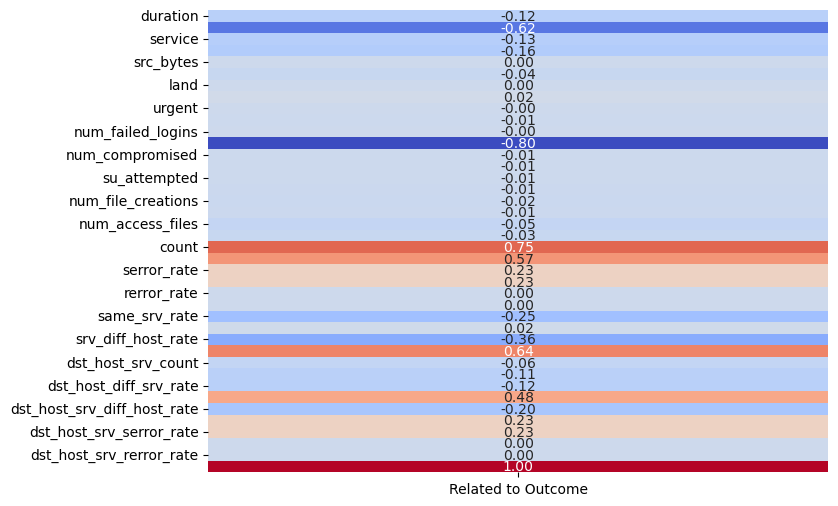

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df2 = df
encode_text(df2, 'outcome')

#Computer correlation between all features and outcome variable
correlation = df2.corrwith(df2['outcome'])

plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(correlation, columns=['Related to Outcome']), annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.yticks(rotation=0)
plt.show()

In [14]:
correlation

duration                      -0.118015
protocol_type                 -0.616600
service                       -0.131724
flag                          -0.155671
src_bytes                      0.000936
dst_bytes                     -0.037709
land                           0.002542
wrong_fragment                 0.023629
urgent                        -0.001498
hot                           -0.006327
num_failed_logins             -0.001060
logged_in                     -0.795280
num_compromised               -0.005046
root_shell                    -0.005871
su_attempted                  -0.008789
num_root                      -0.011006
num_file_creations            -0.018671
num_shells                    -0.014951
num_access_files              -0.054268
is_guest_login                -0.032300
count                          0.752977
srv_count                      0.566828
serror_rate                    0.227739
srv_serror_rate                0.227188
rerror_rate                    0.003189


Features with outcome correlations lower than 0.05 are eliminated from the dataset

In [15]:
row = 0
for num in correlation:
 if num >= -0.05 and num <= 0.05:
     df2.drop(df2.columns[row], axis=1, inplace=True)
     row += 1

df2

,protocol_type,flag,dst_bytes,wrong_fragment,hot,logged_in,root_shell,num_root,num_shells,is_guest_login,...,srv_serror_rate,srv_rerror_rate,diff_srv_rate,dst_host_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,1.0,9.0,-0.011578,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.297125,0.599396,-1.146738,-0.464418,-0.25204,-0.249464,0.0
1,1.0,9.0,0.014179,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.142672,0.599396,-1.188292,-0.464418,-0.25204,-0.249464,0.0
2,1.0,9.0,0.014179,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.988219,0.599396,-1.188292,-0.464418,-0.25204,-0.249464,0.0
3,1.0,9.0,0.035214,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.833766,0.599396,-1.209068,-0.464418,-0.25204,-0.249464,0.0
4,1.0,9.0,0.035214,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.679313,0.599396,-1.209068,-0.464418,-0.25204,-0.249464,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,1.0,9.0,0.030644,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-2.262290,0.599396,-1.229845,-0.464418,-0.25204,-0.249464,0.0
494016,1.0,9.0,0.042902,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.497913,0.599396,-0.897418,-0.464418,-0.25204,-0.249464,0.0
494017,1.0,9.0,0.010033,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.174819,-0.248631,-0.255243,-3.343460,0.599396,-1.125962,-0.306769,-0.25204,-0.249464,0.0
494018,1.0,9.0,0.010033,-0.04772,-0.044136,1.0,-0.010552,-0.00564,-0.009919,0.0,...,-0.463521,-0.248631,-0.255243,-3.189008,0.599396,-1.167515,-0.359319,-0.25204,-0.249464,0.0


In [16]:
df=df2
df["outcome"].value_counts()

outcome
1.0    396743
0.0     97277
Name: count, dtype: int64

## Model Training and Testing
This section focuses on selecting and implementing appropriate models, training them on the preprocessed dataset, and producing evaluation metrics.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import time
import numpy as np

In [18]:
#Split data in training and testing sets
X = df.drop(columns=["outcome"])
y = df["outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
# Create dataframe to store evaluation metrics 
accuracies = pd.DataFrame(columns=["Model", "Accuracy", "F1"])
accuracies

,Model,Accuracy,F1


In [20]:
#Create dataframe to store training and testing times
times = pd.DataFrame(columns=["Model", "Train", "Test"])
times

,Model,Train,Test


### 1. Logistic Regression

In [21]:
start_train = time.time()
lrc = LogisticRegression(random_state=0, max_iter=1000)

parameters = {
    'C':[0.01, 0.1, 1, 10],
    'solver':['lbfgs', 'newton-cholesky']
}

grid_search = GridSearchCV(estimator=lrc, param_grid=parameters, cv=5, scoring='accuracy', verbose=1).fit(X_train, y_train)

best_lr=grid_search.best_estimator_
end_train = time.time()

start_test = time.time()
ypredlr = best_lr.predict(X_test)
end_test = time.time()

print("Train time:", end_train-start_train)
print("Test time:", end_test-start_test)

times.loc[len(times.index)] = ['Logistic Regression',end_train-start_train, end_test-start_test]

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Train time: 54.75826835632324
Test time: 0.007765054702758789


In [22]:
accuracy = accuracy_score(y_test, ypredlr)

f1 = f1_score(y_test, ypredlr)

accuracies.loc[len(accuracies.index)] = ['Logistic Regression', accuracy, f1]


In [23]:
#Cross Validation
cross_val_score(lrc, X, y, cv=10)

array([0.9403263 , 0.97892798, 0.99896765, 0.99580989, 0.99601231,
       0.99801627, 0.99050646, 0.98864418, 0.98931217, 0.58064451])

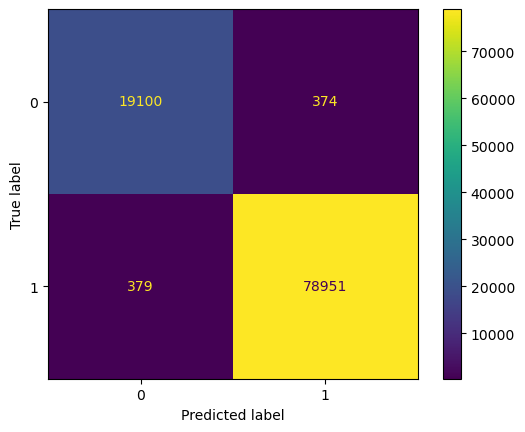

In [24]:
ConfusionMatrixDisplay(confusion_matrix(y_test, ypredlr)).plot()

### 2. Random Forest Classifier

In [25]:
start_train = time.time()
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
end_train = time.time()

start_test = time.time()
y_pred2=rfc.predict(X_test)
end_test = time.time()

print("Train time:", end_train-start_train)
print("Test time:", end_test-start_test)

times.loc[len(times.index)] = ['Random Forest Classifier',end_train-start_train, end_test-start_test]

Train time: 14.243133306503296
Test time: 0.37865662574768066


In [26]:
accuracy = accuracy_score(y_test, y_pred2)
f1 = f1_score(y_test, y_pred2)

accuracies.loc[len(accuracies.index)] = ['Random Forest Classifier', accuracy, f1] 

In [27]:
#Cross Validation
cross_val_score(rfc, X, y, cv=5)

array([0.9716307 , 0.99982794, 0.99978746, 0.99953443, 0.99854257])

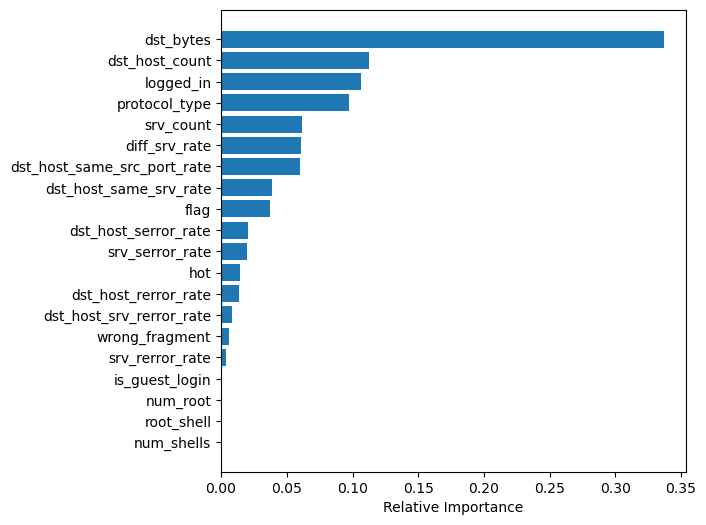

In [28]:
importances = (rfc.feature_importances_)
i = np.argsort(importances)

plt.figure(figsize=(6,6))
plt.barh(range(len(i)), importances[i], align='center')
plt.yticks(range(len(i)), [df.columns[j] for j in i])
plt.xlabel('Relative Importance')
plt.show()

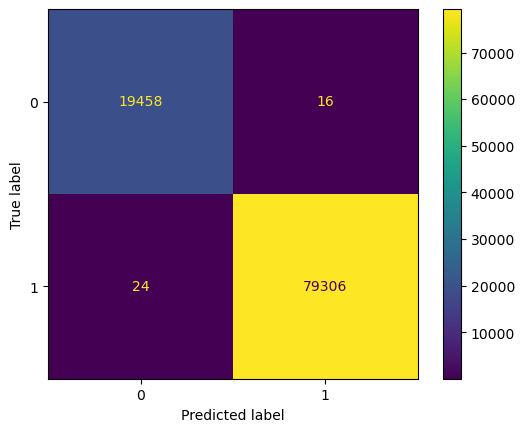

In [29]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred2)).plot()

### 3. Decision Trees

In [30]:
start_train = time.time()
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
end_train = time.time()

start_test = time.time()
y_pred3=dtc.predict(X_test)
end_test = time.time()

print("Train time:", end_train-start_train)
print("Test time:", end_test-start_test)

times.loc[len(times.index)] = ['Decision Tree',end_train-start_train, end_test-start_test]

Train time: 0.8794865608215332
Test time: 0.013674736022949219


In [31]:
accuracy = accuracy_score(y_test,y_pred3)
f1 = f1_score(y_test, y_pred3)

accuracies.loc[len(accuracies.index)] = ['Decision Tree', accuracy, f1] 

In [32]:
#Cross Validation
cross_val_score(dtc, X, y, cv=5)

array([0.98359378, 0.99955467, 0.99940286, 0.99899802, 0.82301324])

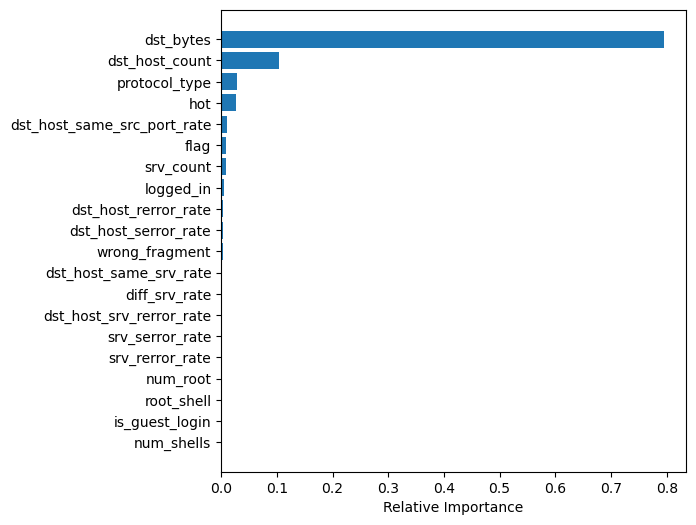

In [33]:
importances = (dtc.feature_importances_)
i = np.argsort(importances)

plt.figure(figsize=(6,6))
plt.barh(range(len(i)), importances[i], align='center')
plt.yticks(range(len(i)), [df.columns[j] for j in i])
plt.xlabel('Relative Importance')
plt.show()

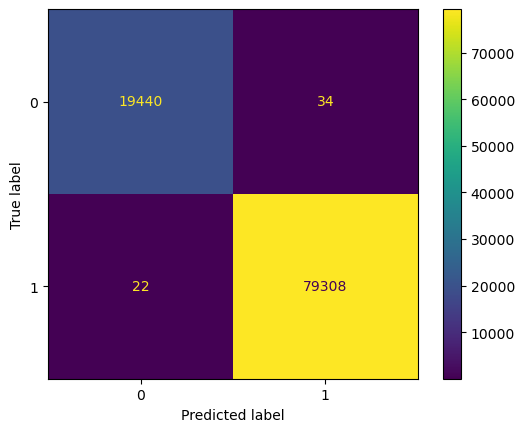

In [34]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred3)).plot()

### 4. SVM

In [35]:
# start_train = time.time()
# svc = SVC()
# svc.fit(X_train, y_train)
# end_train = time.time()

# start_test = time.time()
# y_pred4=svc.predict(X_test)
# end_test = time.time()

# print("Train time:", end_train-start_train)
# print("Test time:", end_test-start_test)

# times.loc[len(times.index)] = ['Support Vector Machine',end_train-start_train, end_test-start_test]

In [36]:
# accuracy = accuracy_score(y_test,y_pred4)
# f1 = f1_score(y_test,y_pred4)
# accuracies.loc[len(accuracies.index)] = ['Support Vector Machine', accuracy, f1] 

In [37]:
# #Cross Validation
# cross_val_score(svc, X, y, cv=5)

In [38]:
# ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred4)).plot()

### 5. Gradient Boost

In [39]:
start_train = time.time()
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)
end_train = time.time()

start_test = time.time()
y_pred5=gbc.predict(X_test)
end_test = time.time()

print("Train time:", end_train-start_train)
print("Test time:", end_test-start_test)

times.loc[len(times.index)] = ['Gradient Boost',end_train-start_train, end_test-start_test]

Train time: 25.982727766036987
Test time: 0.11252546310424805


In [40]:
accuracy = accuracy_score(y_test,y_pred5)
f1 = f1_score(y_test, y_pred5)

accuracies.loc[len(accuracies.index)] = ['Gradient Boost', accuracy, f1] 

In [41]:
#Cross Validation
cross_val_score(gbc, X, y, cv=5)

array([0.98337112, 0.99929153, 0.99782397, 0.99873487, 0.99667018])

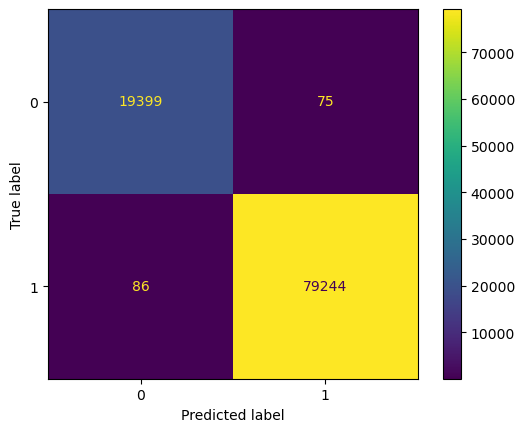

In [42]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred5)).plot()

### 6. Gaussian Naive Bayes

In [43]:
start_train = time.time()
gnb = GaussianNB()
gnb.fit(X_train, y_train)
end_train = time.time()

start_test = time.time()
y_pred6=gnb.predict(X_test)
end_test = time.time()

print("Train time:", end_train-start_train)
print("Test time:", end_test-start_test)

times.loc[len(times.index)] = ['Gaussian Naive Bayes',end_train-start_train, end_test-start_test]

Train time: 0.22565460205078125
Test time: 0.02763509750366211


In [44]:
accuracy = accuracy_score(y_test,y_pred6)
f1 = f1_score(y_test, y_pred6)

accuracies.loc[len(accuracies.index)] = ['Gaussian Naive Bayes', accuracy, f1] 

In [45]:
#Cross Validation
cross_val_score(gnb, X, y, cv=5)

array([0.94126756, 0.99683211, 0.99628558, 0.99197401, 0.75569815])

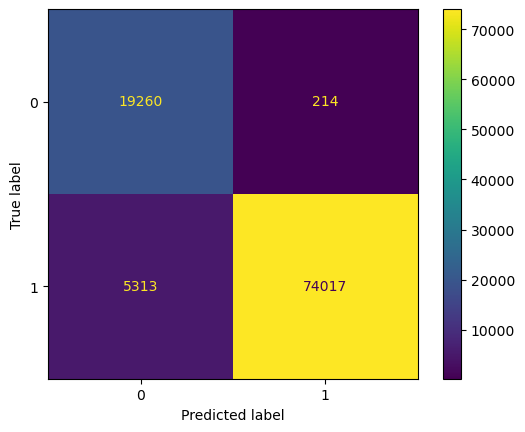

In [46]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred6)).plot()

### 7. Artificial Neural Network

This section of the notebook utilizes tensorflow and keraas to construct an Artificial Neural Network. The ANN is defined with three layers and compiled with the adam optimizer and mean absolute error loss function 

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 64)                1344      
                                                                 
 dense_13 (Dense)            (None, 64)                4160      
                                                                 


 dense_14 (Dense)            (None, 1)                 65        
                                                                 
Total params: 5,569
Trainable params: 5,569
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/12
1544/1544 [==============================] - 5s 3ms/step - loss: 0.0308 - accuracy: 0.9901 - val_loss: 0.0161 - val_accuracy: 0.9940
Epoch 2/12
1544/1544 [==============================] - 4s 3ms/step - loss: 0.0195 - accuracy: 0.9957 - val_loss: 0.0277 - val_accuracy: 0.9960
Epoch 3/12
1544/1544 [==============================] - 4s 3ms/step - loss: 0.0162 - accuracy: 0.9959 - val_loss: 0.0232 - val_accuracy: 0.9961
Epoch 4/12
1544/1544 [==============================] - 4s 2ms/step - loss: 0.0131 - accuracy: 0.9959 - val_loss: 0.0175 - val_accuracy: 0.9955
Epoch 5/12
1544/1544 [==============================] - 4s 2ms/step - loss: 0.0120 - accuracy: 0.9960 - val_loss: 0.0087 - val_accuracy: 0.9961
Epoch 6/1

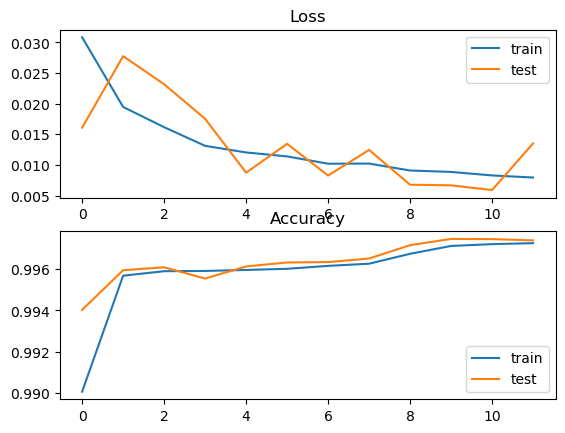

In [62]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from matplotlib import pyplot

input_shape = [X_train.shape[1]]

start_train = time.time()

model = tf.keras.Sequential([
 
    tf.keras.layers.Dense(units=64, activation='relu', input_shape=input_shape),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

model.build()

print(model.summary())

model.compile(optimizer='adam', loss='mae',  metrics=['accuracy'])  

history = model.fit(X_train, y_train, validation_data=(X_test,y_test), batch_size=256, epochs=12,)

end_train=time.time()

# plot loss during training
pyplot.subplot(211)
pyplot.title('Loss')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
# plot accuracy during training
pyplot.subplot(212)
pyplot.title('Accuracy')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='test')
pyplot.legend()
pyplot.show()

times.loc[len(times.index)] = ['ANN',end_train-start_train, end_train-start_train]


In [63]:
accuracy = history.history['accuracy'][11]

accuracies.loc[len(accuracies.index)] = ['ANN', accuracy, 0] 

### View Model Accuracies

In [64]:
accuracies.groupby('Model', group_keys=False).apply(lambda x: x.loc[x.Accuracy.idxmax()])
accuracies.drop_duplicates(subset="Model",inplace=True)    
print(accuracies)

                      Model  Accuracy        F1
0       Logistic Regression  0.992379  0.995254
1  Random Forest Classifier  0.999595  0.999748
2             Decision Tree  0.999433  0.999647
3            Gradient Boost  0.998371  0.998985
4      Gaussian Naive Bayes  0.944061  0.964008
6                       ANN  0.997262  0.000000


<Axes: xlabel='Model'>

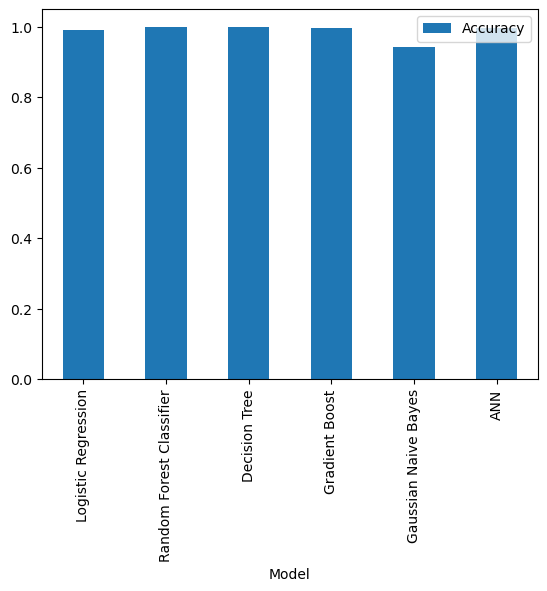

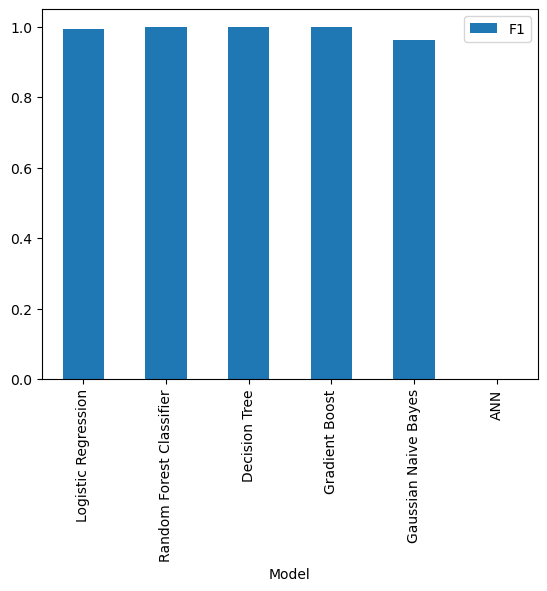

In [65]:
accuracies.plot(kind='bar', x='Model', y='Accuracy')
accuracies.plot(kind='bar', x='Model', y='F1')

In [66]:
print(times)

                      Model      Train       Test
0       Logistic Regression  54.758268   0.007765
1  Random Forest Classifier  14.243133   0.378657
2             Decision Tree   0.879487   0.013675
3            Gradient Boost  25.982728   0.112525
4      Gaussian Naive Bayes   0.225655   0.027635
5                       ANN  82.790484  82.790484
